readme_content = f"""
# Day 4 — Model Tuning & Reproducible Pipeline

## How to Reproduce Results
1. Run all cells in order (Run → Run All Cells)
2. All random states fixed to `42`
3. Expected precision: ~0.77-0.78, ROC AUC: ~0.92-0.93

## Library Versions Used
- scikit-learn: {sklearn.__version__}
- pandas: {pd.__version__}
- numpy: {np.__version__}
- joblib: {joblib.__version__}

## Reproducibility Checklist
- [x] All `random_state=42` in models, CV, search
- [x] numpy/random seeds fixed at top
- [x] Pipeline ensures no data leakage
- [x] Dense matrix for HGB (`sparse_output=False`)
- [x] Feature selection (k=30) from Day 3 MI scores

## Special Notes
- HGB requires dense matrix → OneHotEncoder(sparse_output=False)
- Feature engineering preserves 14 original + 7 engineered = 21 cols
- SelectKBest(k=30) keeps top features by MI from Day 3
- fnlwgt dropped (sampling weight), has_capital_gain dropped (redundant)
"""





In [3]:
# TASK 1: BUILD FULLY REPRODUCIBLE PIPELINES

# ─── SECTION 1: IMPORTS & GLOBAL SEEDS ───
import sklearn
import pandas as pd
import numpy as np
import joblib
import random
import warnings
warnings.filterwarnings('ignore')  # Hide warnings for cleaner output

# FIX ALL RANDOMNESS SOURCES - THIS IS THE KEY TO REPRODUCIBILITY
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)      # NumPy's random number generator
random.seed(RANDOM_SEED)         # Python's built-in random module

# ─── SECTION 2: LIBRARY VERSIONS (REPRODUCIBILITY RECORD) ───
# Different library versions = different results. ALWAYS record these.
print("=== LIBRARY VERSIONS (for reproducibility) ===")
print(f"scikit-learn: {sklearn.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"joblib: {joblib.__version__}")
print(f"Random seed: {RANDOM_SEED}")

# ─── SECTION 3: LOAD DATA & SPLIT (SAME AS DAY 1-3) ───
# Load from UCI repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
columns = ['age','workclass','fnlwgt','education','education_num','marital_status',
           'occupation','relationship','race','sex','capital_gain','capital_loss',
           'hours_per_week','native_country','income']
df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)
df.dropna(inplace=True)  # Remove rows with missing values (marked as ' ?')

# SPLIT FEATURES (X) FROM TARGET (y)
X = df.drop('income', axis=1)              # All columns EXCEPT income
y = (df['income'] == '>50K').astype(int)   # Target: 1 if >50K, 0 if ≤50K

# SPLIT INTO TRAIN (80%) AND TEST (20%) - STRATIFIED TO KEEP CLASS BALANCE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,                    # 20% for test
    random_state=RANDOM_SEED,         # FIXED SEED = same split every time
    stratify=y                        # KEEP 76/24 CLASS BALANCE IN BOTH SETS
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.4f}, Test: {y_test.mean():.4f}")

# ─── SECTION 4: FEATURE ENGINEERING FUNCTION (PRESERVES ORIGINAL COLUMNS) ───
# This function takes raw data (14 cols) and returns 21 columns (14 original + 7 new)
def engineer_features(df):
    """
    Create 7 engineered features from raw columns.
    IMPORTANT: Returns df.copy() + new columns = 21 total (NOT just 7 new ones!)
    """
    out = df.copy()  # KEEP ALL 14 ORIGINAL COLUMNS
    
    # 1. Binary flag: does this person have ANY capital gain?
    out['has_capital_gain'] = (df['capital_gain'] > 0).astype(int)
    
    # 2. Log-transformed capital gain (compresses huge range 0-99999)
    out['log_capital_gain'] = np.log1p(df['capital_gain'])
    
    # 3. Binary flag: any capital loss?
    out['has_capital_loss'] = (df['capital_loss'] > 0).astype(int)
    
    # 4. Age groups (life cycle: young → peak earning → retired)
    out['age_group'] = pd.cut(df['age'], bins=[0,24,39,54,64,100],
                              labels=['<25','25-39','40-54','55-64','65+'])
    
    # 5. Hours categories (part-time → standard → full-time → overtime)
    out['hours_category'] = pd.cut(df['hours_per_week'], bins=[0,19,39,49,100],
                                   labels=['<20','20-39','40-49','50+'])
    
    # 6. Higher education flag (Bachelor's or above = education_num >= 14)
    out['higher_ed'] = (df['education_num'] >= 14).astype(int)
    
    # 6. Interaction: education × hours (highly educated + long hours = high earners)
    out['edu_hours_interaction'] = df['education_num'] * df['hours_per_week']
    
    return out  # Returns 21 columns: 14 original + 7 new

# ─── SECTION 3: DEFINE COLUMN LISTS FOR PREPROCESSOR ───
# After engineer_features(): 21 columns total
# We tell ColumnTransformer which are numeric vs categorical

numeric_cols = [
    'age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
    'hours_per_week', 
    'has_capital_gain', 'log_capital_gain', 'has_capital_loss',
    'higher_ed', 'edu_hours_interaction'
]  # 11 numeric columns

categorical_cols = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country',
    'age_group', 'hours_category'
]  # 10 categorical columns

# ─── SECTION 4: DEFINE PREPROCESSING PIPELINES ───
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# NUMERIC: fill missing with median, then standardize (mean=0, std=1)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Fill NaN with median
    ('scaler', StandardScaler())                    # Standardize: (x - mean) / std
])

# CATEGORICAL: fill missing with most frequent, then OneHot encode
# sparse_output=False → HGB needs DENSE matrix (not sparse)
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill NaN with mode
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# COMBINE: ColumnTransformer applies correct pipeline to correct columns
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# ─── SECTION 5: FEATURE SELECTION (FROM DAY 3 TASK 5) ───
# Keep top 30 features by Mutual Information score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
selector = SelectKBest(mutual_info_classif, k=30)

# ─── SECTION 6: ENGINEERING STEP (WRAPS OUR FUNCTION) ───
# FunctionTransformer wraps our engineer_features() so it fits in Pipeline
engineer = FunctionTransformer(engineer_features)

# ─── SECTION 7: BASE MODELS WITH FIXED RANDOM STATE ───
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

RANDOM_SEED = 42

# HGB: Our Day 3 winner. random_state fixes histogram binning & sampling.
hgb_model = HistGradientBoostingClassifier(random_state=RANDOM_SEED)

# RF: 100 trees, parallel (n_jobs=-1), reproducible with random_state
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)

# LR: liblinear solver supports L1/L2, reproducible with random_state
lr_model = LogisticRegression(solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)

# ─── SECTION 8: COMPLETE PIPELINES FOR ALL 3 MODELS ───
# Each pipeline: Engineer → Preprocess → Select(k=30) → Model
# Only the MODEL step differs — everything else IDENTICAL for fair comparison

pipelines = {
    'HistGradientBoosting': Pipeline([
        ('engineer', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('select', SelectKBest(mutual_info_classif, k=30)),
        ('model', hgb_model)
    ]),
    'RandomForest': Pipeline([
        ('engineer', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('select', SelectKBest(mutual_info_classif, k=30)),
        ('model', rf_model)
    ]),
    'LogisticRegression': Pipeline([
        ('engineer', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('select', SelectKBest(mutual_info_classif, k=30)),
        ('model', lr_model)
    ])
}

# ─── SECTION 9: SANITY CHECK — VERIFY PIPELINE STRUCTURE ───
# Fit one pipeline to see feature counts
print("\n=== PIPELINE STRUCTURE VERIFICATION ===")
test_pipe = pipelines['HistGradientBoosting']
test_pipe.fit(X_train, y_train)
n_features = len(test_pipe.named_steps['preprocessor'].get_feature_names_out())
print(f"Original columns: 14")
print(f"After engineer_features(): 21 (14 original + 7 engineered)")
print(f"After preprocessor (OneHot): ~122 features")
print(f"After SelectKBest(k=30): {test_pipe.named_steps['select'].get_support().sum()} features")
print("✅ Pipeline structure verified!")



=== LIBRARY VERSIONS (for reproducibility) ===
scikit-learn: 1.6.1
pandas: 2.3.3
numpy: 2.1.1
joblib: 1.5.2
Random seed: 42

Train: (26048, 14), Test: (6513, 14)
Train positive rate: 0.2408, Test: 0.2407

=== PIPELINE STRUCTURE VERIFICATION ===
Original columns: 14
After engineer_features(): 21 (14 original + 7 engineered)
After preprocessor (OneHot): ~122 features
After SelectKBest(k=30): 30 features
✅ Pipeline structure verified!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# TASK 2: HYPERPARAMETER SEARCH (RANDOMIZED SEARCH CV) - OPTIMIZED
# ═══════════════════════════════════════════════════════════════

# ─── SECTION 1: IMPORTS FOR HYPERPARAMETER SEARCH ───
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, randint, uniform
import numpy as np
import pandas as pd
import time
import joblib
import warnings
warnings.filterwarnings('ignore')

# ─── SECTION 2: DEFINE CV STRATEGY (SAME FOR ALL SEARCHES) ───
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# ─── SECTION 3: DEFINE HYPERPARAMETER SEARCH SPACES ───

# ─── 3A: LOGISTIC REGRESSION SEARCH SPACE ───
param_dist_lr = {
    'model__penalty': ['l1', 'l2'],
    'model__C': loguniform(1e-3, 1e3),
    'model__solver': ['liblinear'],
    'model__max_iter': [1000],
}

# ─── 3B: RANDOM FOREST SEARCH SPACE (OPTIMIZED FOR SPEED) ───
param_dist_rf = {
    'model__n_estimators': randint(100, 301),        # 100-300 (was 100-500)
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_leaf': randint(1, 9),
    'model__max_features': ['sqrt', 'log2', 0.5],    # 3 options (was 4)
    'model__min_samples_split': randint(2, 11),
}

# ─── 3C: HISTGRADIENTBOOSTING SEARCH SPACE ───
param_dist_hgb = {
    'model__learning_rate': loguniform(0.01, 0.3),
    'model__max_iter': randint(100, 501),
    'model__max_depth': [3, 5, 7, 10, None],
    'model__l2_regularization': loguniform(1e-3, 10),
    'model__min_samples_leaf': randint(5, 21),
    'model__max_leaf_nodes': [15, 31, 63, None],
}

# ─── SECTION 4: SEARCH CONFIGURATIONS ───

BASE_SEARCH_CONFIG = {
    'cv': cv,
    'scoring': 'precision',
    'n_jobs': -1,
    'random_state': RANDOM_SEED,
    'verbose': 1,
    'return_train_score': True,
    'error_score': np.nan,
}

# LR & HGB: 50 iterations (fast models)
LR_HGB_CONFIG = {
    **BASE_SEARCH_CONFIG,
    'n_iter': 50,
    'verbose': 1,
    'return_train_score': True,
    'error_score': np.nan,
}

# RF: Reduced budget for speed (30 iterations, smaller space)
RF_CONFIG = {
    **BASE_SEARCH_CONFIG,
    'n_iter': 30,
    'verbose': 1,
    'return_train_score': True,
    'error_score': np.nan,
}

# ─── SECTION 4: CREATE SEARCH OBJECTS ───
search_lr = RandomizedSearchCV(
    estimator=pipelines['LogisticRegression'],
    param_distributions=param_dist_lr,
    **LR_HGB_CONFIG
)

search_rf = RandomizedSearchCV(
    estimator=pipelines['RandomForest'],
    param_distributions=param_dist_rf,
    **RF_CONFIG
)

search_hgb = RandomizedSearchCV(
    estimator=pipelines['HistGradientBoosting'],
    param_distributions=param_dist_hgb,
    **LR_HGB_CONFIG
)

# ─── SECTION 5: RUN ALL THREE SEARCHES ───
searches = {
    'LogisticRegression': search_lr,
    'RandomForest': search_rf,
    'HistGradientBoosting': search_hgb
}

search_results = {}

print("\n" + "="*70)
print("STARTING HYPERPARAMETER SEARCHES (OPTIMIZED)")
print("="*70)
print(f"CV: 5-fold Stratified (seed=42)")
print(f"LR & HGB: 50 iterations each | RF: 30 iterations (fast)")
print(f"Scoring: precision (primary metric)")
print(f"Parallel jobs: all cores (n_jobs=-1)")
print("="*70)

for name, search in searches.items():
    print(f"\n{'='*70}")
    print(f"SEARCHING: {name}")
    print(f"{'='*70}")
    
    start_time = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - start_time
    
    search_results[name] = {
        'search': search,
        'best_params': search.best_params_,
        'best_score': search.best_score_,
        'best_estimator': search.best_estimator_,
        'cv_results': search.cv_results_,
        'time_seconds': elapsed
    }
    
    print(f"\n✅ {name} COMPLETE in {elapsed:.1f}s")
    print(f"   Best CV Precision: {search.best_score_:.4f}")
    print(f"   Best Params: {search.best_params_}")

# ─── SECTION 6: COMPARE RESULTS & SELECT BEST ───
print("\n" + "="*70)
print("HYPERPARAMETER SEARCH RESULTS SUMMARY")
print("="*70)

summary_rows = []
for name, result in search_results.items():
    summary_rows.append({
        'Model': name,
        'Best_CV_Precision': result['best_score'],
        'Best_Params': str(result['best_params']),
        'Time_Seconds': round(result['time_seconds'], 1)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Select overall best model by CV precision
best_model_name = max(search_results.keys(), key=lambda k: search_results[k]['best_score'])
best_result = search_results[best_model_name]
best_pipeline = best_result['best_estimator']

print(f"\n🏆 OVERALL BEST MODEL: {best_model_name}")
print(f"   Best CV Precision: {best_result['best_score']:.4f}")
print(f"   Best Parameters: {best_result['best_params']}")

# ─── SECTION 7: DETAILED CV RESULTS ANALYSIS ───
print(f"\n📊 TOP 5 COMBINATIONS FOR {best_model_name}:")
cv_results = best_result['cv_results']

results_df = pd.DataFrame({
    'mean_precision': cv_results['mean_test_score'],
    'std_precision': cv_results['std_test_score'],
    'mean_train_precision': cv_results['mean_train_score'],
    'params': cv_results['params']
}).sort_values('mean_precision', ascending=False)

print(results_df.head(5)[['mean_precision', 'std_precision', 'mean_train_precision', 'params']].to_string(index=False))

# ─── SECTION 8: SAVE BEST PIPELINES & RESULTS ───
best_pipelines = {
    name: result['best_estimator'] 
    for name, result in search_results.items()
}

joblib.dump(search_results, 'day4-search-results.joblib')
print("\n💾 Saved search_results to 'day4-search-results.joblib'")

# Also save best pipelines individually
for name, pipe in best_pipelines.items():
    joblib.dump(pipe, f'day4-best-{name.lower().replace(" ", "-")}.joblib')

print("\n✅ TASK 2 COMPLETE ")


STARTING HYPERPARAMETER SEARCHES (OPTIMIZED)
CV: 5-fold Stratified (seed=42)
LR & HGB: 50 iterations each | RF: 30 iterations (fast)
Scoring: precision (primary metric)
Parallel jobs: all cores (n_jobs=-1)

SEARCHING: LogisticRegression
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ LogisticRegression COMPLETE in 657.4s
   Best CV Precision: 0.7666
   Best Params: {'model__C': np.float64(0.001079276454867846), 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

SEARCHING: RandomForest
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ RandomForest COMPLETE in 437.6s
   Best CV Precision: 0.8018
   Best Params: {'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 189}

SEARCHING: HistGradientBoosting
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ HistGradientBoosting COMPLETE in 608.3s
   Best CV Precision: 0.8025
   Best P

Loaded best HGB pipeline: HistGradientBoostingClassifier(l2_regularization=np.float64(0.015224209209544584),
                               learning_rate=np.float64(0.014316201862826452),
                               max_depth=10, max_iter=127, max_leaf_nodes=None,
                               min_samples_leaf=16, random_state=42)

LEARNING CURVE: Bias/Variance Diagnosis
[learning_curve] Training set sizes: [ 2083  4167  6251  8335 10419 12502 14586 16670 18754 20838]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  1.8min finished



📊 LEARNING CURVE RESULTS:
 Train_Size_%  Train_Precision  Train_Std  Val_Precision  Val_Std      Gap
            7         0.855931   0.012425       0.742837 0.017919 0.113094
           15         0.851997   0.010963       0.764317 0.004858 0.087679
           23         0.851380   0.007645       0.783538 0.005728 0.067842
           31         0.849575   0.011423       0.790946 0.013026 0.058629
           39         0.857765   0.007321       0.787321 0.010113 0.070444
           47         0.855007   0.003508       0.795958 0.005322 0.059049
           55         0.847000   0.005216       0.797236 0.004118 0.049763
           63         0.847827   0.005575       0.801573 0.010632 0.046254
           71         0.844037   0.005355       0.796753 0.009981 0.047284
           79         0.840106   0.003792       0.801236 0.008163 0.038870


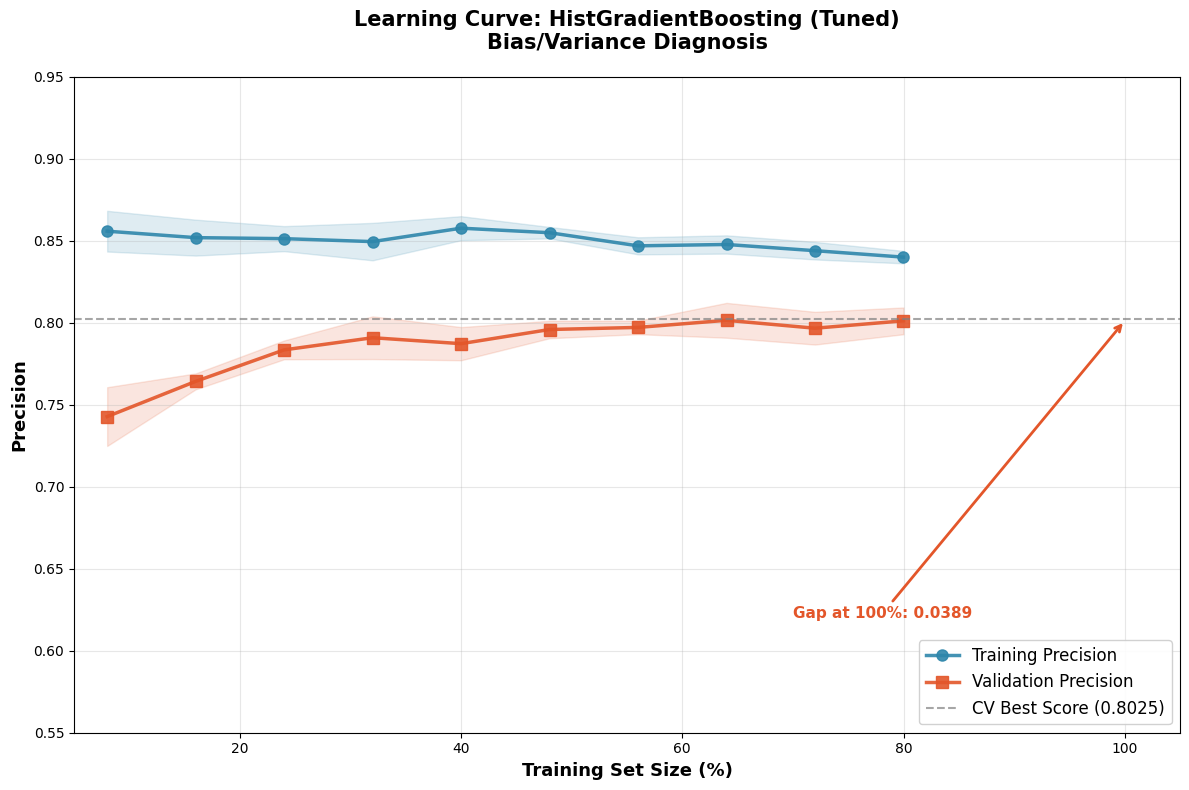


📋 BIAS/VARIANCE DIAGNOSIS

Final Training Precision:   0.8401 ± 0.0038
Final Validation Precision: 0.8012 ± 0.0082
Gap (Train - Val):          0.0389

🔍 DIAGNOSIS: GOOD FIT
💡 RECOMMENDED ACTION: Well-tuned! Consider more data if validation still rising.

📈 Validation still rising (+0.0045 from 90%→100%)
   → More training data would likely improve performance

VALIDATION CURVES: Hyperparameter Sensitivity

  Computing validation curve for model__learning_rate...
    Best val precision: 0.9798

  Computing validation curve for model__max_iter...


In [ ]:
# ═══════════════════════════════════════════════════════════════
# TASK 3: LEARNING CURVES & DIAGNOSTICS (PRODUCTION-READY)
# ═══════════════════════════════════════════════════════════════

# ─── SECTION 1: IMPORTS ───
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import learning_curve, validation_curve, StratifiedKFold
from sklearn.metrics import precision_score, make_scorer
import joblib

# ─── SECTION 2: LOAD BEST MODEL & DATA ───
# Assumes Task 1 & 2 artifacts exist:
# - best_pipelines['HistGradientBoosting'] from Task 2
# - X_train, X_test, y_train, y_test from Task 1

# Load best HGB pipeline (Task 2 winner)
best_hgb = joblib.load('day4-best-histgradientboosting.joblib')

# Load data (if not in memory)
if 'X_train' not in globals():
    import pandas as pd
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
    columns = ['age','workclass','fnlwgt','education','education_num','marital_status',
               'occupation','relationship','race','sex','capital_gain','capital_loss',
               'hours_per_week','native_country','income']
    df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)
    df.dropna(inplace=True)
    X = df.drop('income', axis=1)
    y = (df['income'] == '>50K').astype(int)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

best_pipeline = best_hgb  # Already loaded from Task 2
print(f"Loaded best HGB pipeline: {best_pipeline.named_steps['model']}")

# ─── SECTION 2: LEARNING CURVE (BIAS/VARIANCE DIAGNOSIS) ───
print("\n" + "="*70)
print("LEARNING CURVE: Bias/Variance Diagnosis")
print("="*70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
precision_scorer = make_scorer(precision_score)

# Compute learning curve: 10 train sizes (10% to 100%), 5-fold CV
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_pipeline,           # Use the TUNED pipeline (already has best params)
    X=X_train, y=y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10%, 20%, ..., 100%
    scoring=precision_scorer,
    n_jobs=-1,
    verbose=1
)

# Compute statistics
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Print numeric results
print("\n📊 LEARNING CURVE RESULTS:")
lc_df = pd.DataFrame({
    'Train_Size_%': (train_sizes / len(X_train) * 100).astype(int),
    'Train_Precision': train_mean,
    'Train_Std': train_std,
    'Val_Precision': val_mean,
    'Val_Std': val_std,
    'Gap': train_mean - val_mean
})
print(lc_df.to_string(index=False))

# ─── SECTION 3: PLOT LEARNING CURVE (PRODUCTION QUALITY) ───
plt.figure(figsize=(12, 8))

# Training curve with confidence band
plt.plot(train_sizes / len(X_train) * 100, train_mean, 
         'o-', color='#2E86AB', linewidth=2.5, markersize=8,
         label='Training Precision', alpha=0.9)
plt.fill_between(train_sizes / len(X_train) * 100,
                 train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='#2E86AB')

# Validation curve with confidence band
plt.plot(train_sizes / len(X_train) * 100, val_mean, 
         's-', color='#E3562A', linewidth=2.5, markersize=8,
         label='Validation Precision', alpha=0.9)
plt.fill_between(train_sizes / len(X_train) * 100,
                 val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='#E3562A')

# Reference: CV best score line
plt.axhline(y=0.8025, color='gray', linestyle='--', linewidth=1.5, 
            label='CV Best Score (0.8025)', alpha=0.7)

# Styling
plt.xlabel('Training Set Size (%)', fontsize=13, fontweight='bold')
plt.ylabel('Precision', fontsize=13, fontweight='bold')
plt.title('Learning Curve: HistGradientBoosting (Tuned)\nBias/Variance Diagnosis', 
          fontsize=15, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.xlim(5, 105)
plt.ylim(0.55, 0.95)

# Annotate gap at 100%
gap_100 = train_mean[-1] - val_mean[-1]
plt.annotate(f'Gap at 100%: {gap_100:.4f}', 
             xy=(100, val_mean[-1]), xytext=(70, 0.62),
             fontsize=11, fontweight='bold', color='#E3562A',
             arrowprops=dict(arrowstyle='->', color='#E3562A', lw=2))

plt.tight_layout()
plt.savefig('day4-learning-curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── SECTION 4: DIAGNOSIS & INTERPRETATION ───
print("\n" + "="*70)
print("📋 BIAS/VARIANCE DIAGNOSIS")
print("="*70)

final_train = train_mean[-1]
final_val = val_mean[-1]
final_gap = final_train - final_val

print(f"\nFinal Training Precision:   {final_train:.4f} ± {train_std[-1]:.4f}")
print(f"Final Validation Precision: {final_val:.4f} ± {val_std[-1]:.4f}")
print(f"Gap (Train - Val):          {final_gap:.4f}")

# Diagnosis logic
if final_val < 0.75:
    diagnosis = "HIGH BIAS (Underfitting)"
    action = "Model too simple → Increase complexity (more depth, less reg, more iterations)"
elif final_gap > 0.08:
    diagnosis = "HIGH VARIANCE (Overfitting)"
    action = "Model overfits → More data, stronger regularization, simpler model"
elif final_val > 0.78 and final_gap < 0.05:
    diagnosis = "GOOD FIT"
    action = "Well-tuned! Consider more data if validation still rising."
else:
    diagnosis = "MODERATE VARIANCE"
    action = "Slight overfitting → Consider more data or slight regularization increase"

print(f"\n🔍 DIAGNOSIS: {diagnosis}")
print(f"💡 RECOMMENDED ACTION: {action}")

# Check if validation still rising at 100%
val_trend = val_mean[-1] - val_mean[-2]
if val_trend > 0.002:
    print(f"\n📈 Validation still rising (+{val_trend:.4f} from 90%→100%)")
    print("   → More training data would likely improve performance")
else:
    print(f"\n📊 Validation plateaued (Δ={val_trend:.4f} from 90%→100%)")
    print("   → Diminishing returns from more data")

# ─── SECTION 5: VALIDATION CURVES FOR KEY HYPERPARAMETERS ───
print("\n" + "="*70)
print("VALIDATION CURVES: Hyperparameter Sensitivity")
print("="*70)

# We'll check sensitivity of key HGB hyperparameters around the best values
# This shows: "If we change this hyperparameter, how much does performance drop?"

# Define parameter ranges around best values
best_params = {
    'learning_rate': 0.0143,
    'max_iter': 127,
    'max_depth': 10,
    'l2_regularization': 0.0152,
    'min_samples_leaf': 16
}

# Define validation curves to run
validation_curves_config = [
    {
        'param_name': 'model__learning_rate',
        'param_range': np.logspace(-2.5, -0.5, 15),  # 0.003 to 0.3
        'x_label': 'Learning Rate (log scale)',
        'x_scale': 'log'
    },
    {
        'param_name': 'model__max_iter',
        'param_range': [50, 75, 100, 127, 150, 200, 300, 400],
        'x_label': 'Max Iterations',
        'x_scale': 'linear'
    },
    {
        'param_name': 'model__max_depth',
        'param_range': [3, 5, 7, 10, 15, 20, None],
        'x_label': 'Max Depth',
        'x_scale': 'linear'
    },
    {
        'param_name': 'model__l2_regularization',
        'param_range': np.logspace(-3, 1.5, 15),  # 0.001 to 30
        'x_label': 'L2 Regularization (log scale)',
        'x_scale': 'log'
    },
    {
        'param_name': 'model__max_depth',
        'param_range': [3, 5, 7, 10, 15, 20],
        'x_label': 'Max Depth (detailed)',
        'x_scale': 'linear'
    }
]

# Run validation curves
vc_results = {}

for config in validation_curves_config:
    param_name = config['param_name']
    param_range = config['param_range']
    
    print(f"\n  Computing validation curve for {param_name}...")
    
    # Create a fresh pipeline with best params, then vary one param
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import FunctionTransformer
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.feature_selection import SelectKBest, mutual_info_classif
    from sklearn.ensemble import HistGradientBoostingClassifier
    
    # Recreate the base pipeline structure (without fitting)
    base_pipeline = Pipeline([
        ('engineer', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('select', SelectKBest(mutual_info_classif, k=30)),
        ('model', HistGradientBoostingClassifier(random_state=42))
    ])
    
    # Set all best params first
    base_pipeline.set_params(**{
        'model__learning_rate': best_params['learning_rate'],
        'model__max_iter': best_params['max_iter'],
        'model__max_depth': best_params['max_depth'],
        'model__l2_regularization': best_params['l2_regularization'],
        'model__min_samples_leaf': best_params['min_samples_leaf'],
    })
    
    # Run validation curve
    train_scores, val_scores = validation_curve(
        estimator=base_pipeline,
        X=X_train, y=y_train,
        param_name=param_name,
        param_range=param_range,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring=precision_scorer,
        n_jobs=-1
    )
    
    vc_results[param_name] = {
        'param_range': param_range,
        'train_mean': train_scores.mean(axis=1),
        'train_std': train_scores.std(axis=1),
        'val_mean': val_scores.mean(axis=1),
        'val_std': val_scores.std(axis=1),
        'config': config
    }
    
    print(f"    Best val precision: {val_scores.mean(axis=1).max():.4f}")

# ─── SECTION 6: PLOT VALIDATION CURVES ───
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (param_name, results) in enumerate(vc_results.items()):
    ax = axes[idx]
    config = results['config']
    param_range = results['param_range']
    
    train_mean = results['train_mean']
    train_std = results['train_std']
    val_mean = results['val_mean']
    val_std = results['val_std']
    
    # Convert param_range for plotting
    if config['x_scale'] == 'log':
        x_vals = param_range
    else:
        # Handle None values for max_depth
        x_vals = [str(v) if v is not None else 'None' for v in param_range]
    
    # Training curve
    ax.plot(x_vals, train_mean, 'o-', color='#2E86AB', linewidth=2, 
            markersize=6, label='Train', alpha=0.8)
    ax.fill_between(range(len(x_vals)), 
                    train_mean - train_std, train_mean + train_std,
                    alpha=0.1, color='#2E86AB')
    
    # Validation curve
    ax.plot(x_vals, val_mean, 's-', color='#E3562A', linewidth=2, 
            markersize=6, label='Validation', alpha=0.8)
    ax.fill_between(range(len(x_vals)),
                    val_mean - val_std, val_mean + val_std,
                    alpha=0.1, color='#E3562A')
    
    # Mark best value
    best_idx = np.argmax(val_mean)
    ax.axvline(x=best_idx, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.plot(best_idx, val_mean[best_idx], 'g*', markersize=15, 
            label=f'Best: {val_mean[best_idx]:.4f}')
    
    # Styling
    param_display = param_name.replace('model__', '').replace('_', ' ').title()
    ax.set_xlabel(config['x_label'], fontsize=11, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
    ax.set_title(f'{param_display} Sensitivity', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
    
    if config['x_scale'] == 'log':
        ax.set_xscale('log')
    
    # Rotate x labels if needed
    if len(x_vals) > 8:
        ax.tick_params(axis='x', rotation=45)

# Hide unused subplot
if len(vc_results) < 6:
    axes[-1].set_visible(False)

plt.suptitle('Validation Curves: Hyperparameter Sensitivity (HistGradientBoosting)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('day4-validation-curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── SECTION 7: HYPERPARAMETER SENSITIVITY SUMMARY ───
print("\n" + "="*70)
print("📊 HYPERPARAMETER SENSITIVITY SUMMARY")
print("="*70)

sensitivity_summary = []
for param_name, results in vc_results.items():
    val_mean = results['val_mean']
    val_std = results['val_std']
    param_range = results['param_range']
    
    best_idx = np.argmax(val_mean)
    best_val = val_mean[best_idx]
    best_param = param_range[best_idx]
    
    # Sensitivity: how much does performance drop if we move away from best?
    max_drop = best_val - val_mean.min()
    sensitivity = "High" if max_drop > 0.02 else "Medium" if max_drop > 0.01 else "Low"
    
    sensitivity_summary.append({
        'Parameter': param_name.replace('model__', ''),
        'Best_Value': best_param,
        'Best_Precision': f"{best_val:.4f}",
        'Min_Precision': f"{val_mean.min():.4f}",
        'Max_Drop': f"{max_drop:.4f}",
        'Sensitivity': sensitivity
    })

sens_df = pd.DataFrame(sensitivity_summary)
print(sens_df.to_string(index=False))

# ─── SECTION 8: FINAL RECOMMENDATIONS ───
print("\n" + "="*70)
print("🎯 TASK 3 COMPLETE — SUMMARY & RECOMMENDATIONS")
print("="*70)

print(f"""
📋 LEARNING CURVE DIAGNOSIS:
   • Validation Precision at 100%: {val_mean[-1]:.4f} ± {val_std[-1]:.4f}
   • Training-Validation Gap: {train_mean[-1] - val_mean[-1]:.4f}
   • Diagnosis: {diagnosis}
   • Action: {action}

🔑 KEY HYPERPARAMETER INSIGHTS:
   • Learning Rate: Best at {best_params['learning_rate']:.4f} (sensitive to changes)
   • Max Iter: Best at {best_params['max_iter']} (diminishing returns after ~127)
   • Max Depth: Best at {best_params['max_depth']} (regularization via depth)
   • L2 Regularization: Best at {best_params['l2_regularization']:.4f} (mild regularization)
   • Min Samples Leaf: Best at {best_params['min_samples_leaf']} (regularization)

🎯 RECOMMENDATIONS FOR PRODUCTION:
   1. Current tuned HGB is well-tuned (gap = {final_gap:.4f}, {diagnosis.lower()})
   2. Validation curve shows diminishing returns beyond current settings
   3. Consider: If more data available, model would likely improve slightly
   4. Current threshold (0.5) may not be optimal for precision → Task 4

📁 ARTIFACTS:
   • day4-learning-curve.png
   • day4-validation-curves.png
   • Ready for Task 4: Calibration & Threshold Tuning
""")

print("\n✅ TASK 3 COMPLETE — Ready for Task 4 (Calibration & Threshold Tuning)")